In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
movies = pd.read_csv("../data/processed/movies_clean.csv")
ratings = pd.read_csv("../data/processed/ratings_clean.csv")

print("Movies:", movies.shape)
print("Ratings:", ratings.shape)

Movies: (58098, 3)
Ratings: (27753444, 4)


2. Rating Distribution


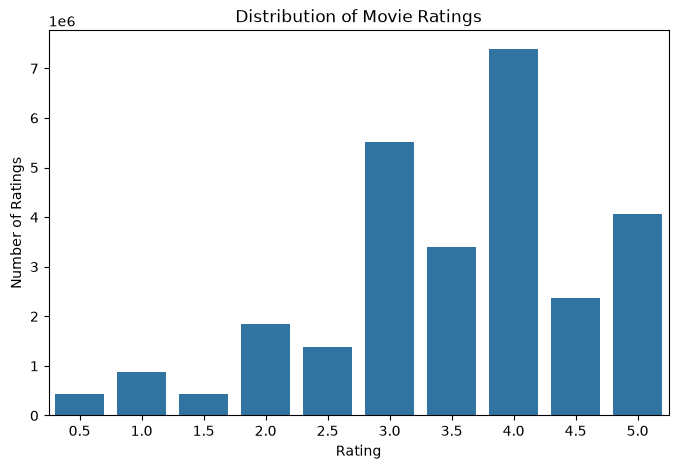

In [27]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=ratings,
    x="rating"
)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.savefig(
    "../outputs/figures/rating_distribution.png",
    bbox_inches="tight"
)

plt.show()
plt.show()

3. Most Rated Movies

First count ratings for every movie:

In [4]:
movie_rating_counts = (
    ratings.groupby("movieId")
    .size()
    .reset_index(name="rating_count")
)

In [5]:
most_rated = movie_rating_counts.merge(
    movies,
    on="movieId"
)

In [6]:
top_10_rated = most_rated.sort_values(
    "rating_count",
    ascending=False
).head(10)

In [7]:
top_10_rated[["title", "rating_count"]]

,title,rating_count
315,"Shawshank Redemption, The (1994)",97999
352,Forrest Gump (1994),97040
293,Pulp Fiction (1994),92406
587,"Silence of the Lambs, The (1991)",87899
2487,"Matrix, The (1999)",84545
257,Star Wars: Episode IV - A New Hope (1977),81815
476,Jurassic Park (1993),76451
523,Schindler's List (1993),71516
108,Braveheart (1995),68803
0,Toy Story (1995),68469


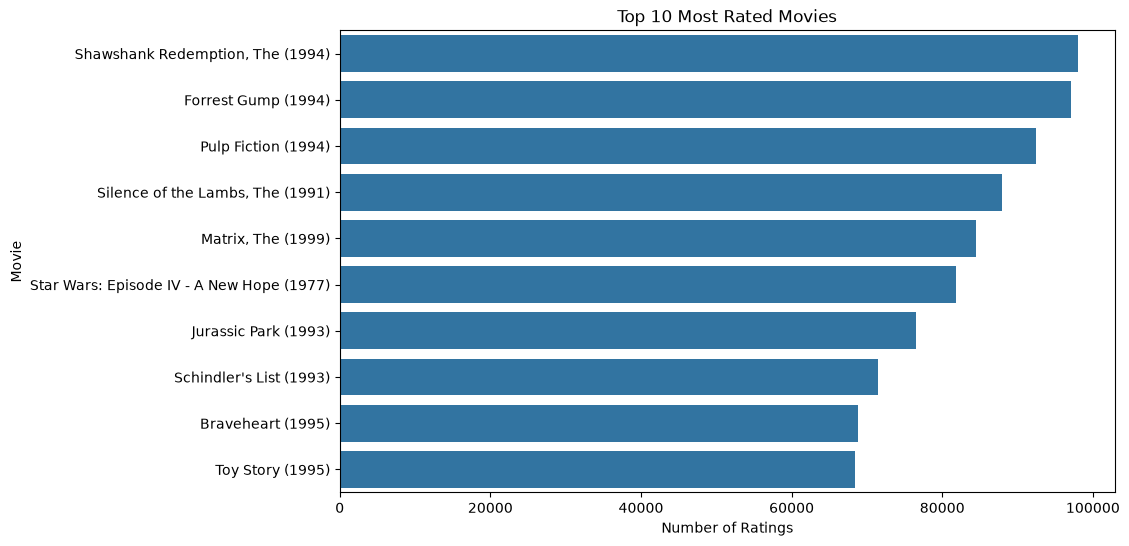

In [8]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10_rated,
    x="rating_count",
    y="title"
)

plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie")
plt.show()

4. Average Rating Distribution

Calculate average rating for each movie:

In [9]:
movie_avg_rating = (
    ratings.groupby("movieId")["rating"]
    .mean()
    .reset_index(name="average_rating")
)

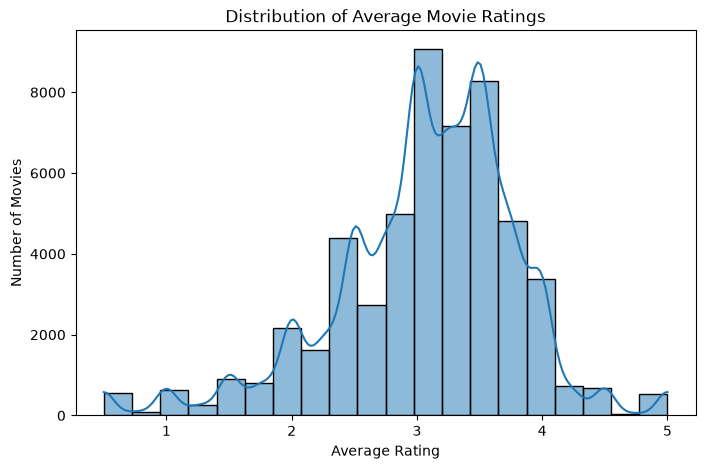

In [26]:
plt.figure(figsize=(8, 5))

sns.histplot(
    movie_avg_rating["average_rating"],
    bins=20,
    kde=True
)

plt.title("Distribution of Average Movie Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Number of Movies")
plt.savefig(
    "../outputs/figures/average_rating_distribution.png",
    bbox_inches="tight"
)

plt.show()
plt.show()

5. Movies by Genre

The genres column contains values like:
Action|Adventure|Sci-Fi

In [11]:
genre_data = movies.copy()

genre_data["genres"] = genre_data["genres"].fillna("")

In [12]:
genre_data["genres"] = genre_data["genres"].str.split("|")

In [13]:
genre_data = genre_data.explode("genres")

In [14]:
genre_counts = (
    genre_data["genres"]
    .value_counts()
    .head(15)
)

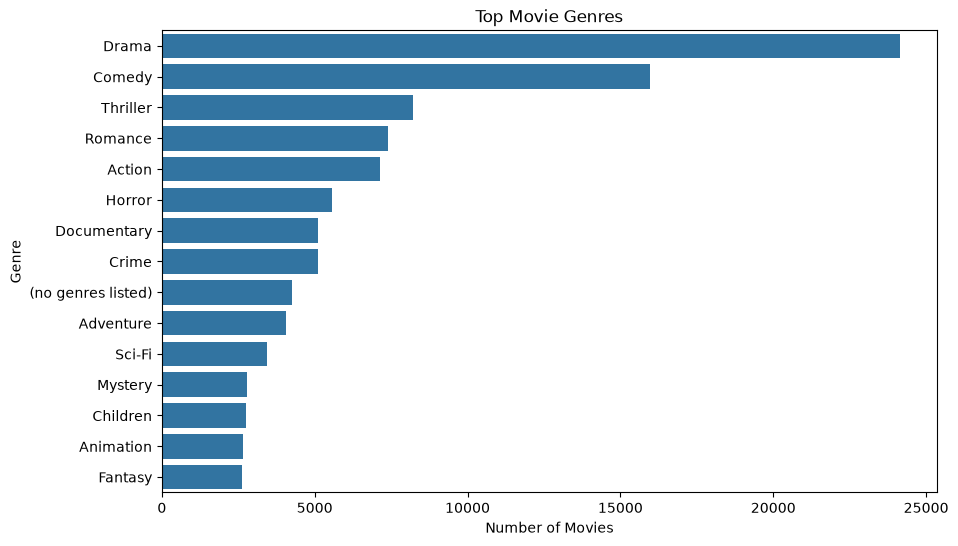

In [25]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index
)

plt.title("Top Movie Genres")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.savefig(
    "../outputs/figures/genre_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

6. User Rating Activity

Find how many ratings each user has given:

In [16]:
user_activity = (
    ratings.groupby("userId")
    .size()
)

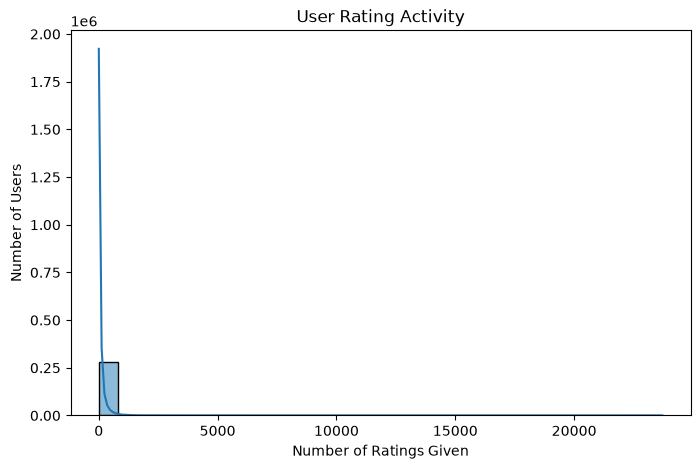

In [24]:
plt.figure(figsize=(8, 5))

sns.histplot(
    user_activity,
    bins=30,
    kde=True
)

plt.title("User Rating Activity")
plt.xlabel("Number of Ratings Given")
plt.ylabel("Number of Users")

plt.savefig(
    "../outputs/figures/user_activity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

7. Movies Released by Year

Movie titles contain the year, for example:

Toy Story (1995)

In [18]:
movies["year"] = (
    movies["title"]
    .str.extract(r"\((\d{4})\)")
)

In [19]:
movies["year"] = pd.to_numeric(
    movies["year"],
    errors="coerce"
)

In [20]:
movies_per_year = (
    movies["year"]
    .value_counts()
    .sort_index()
)

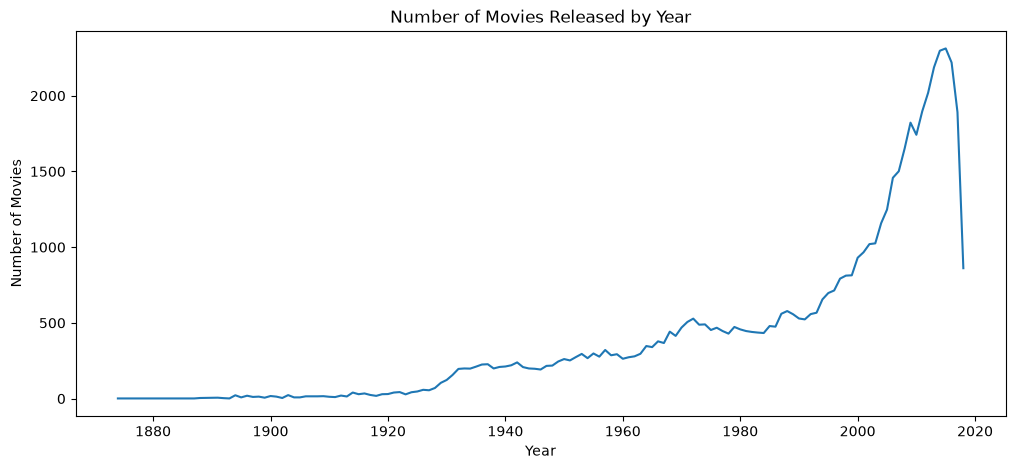

In [21]:
plt.figure(figsize=(12, 5))

plt.plot(
    movies_per_year.index,
    movies_per_year.values
)

plt.title("Number of Movies Released by Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")

plt.savefig(
    "../outputs/figures/rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ratings = pd.read_csv("../data/processed/ratings_clean.csv")

print(ratings.shape)
print(ratings.columns)
print(ratings["rating"].head())
print(ratings["rating"].value_counts().sort_index())

(27753444, 4)
Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='str')
0    3.5
1    3.5
2    1.5
3    4.5
4    4.5
Name: rating, dtype: float64
rating
0.5     442388
1.0     886233
1.5     441354
2.0    1850627
2.5    1373419
3.0    5515668
3.5    3404360
4.0    7394710
4.5    2373550
5.0    4071135
Name: count, dtype: int64


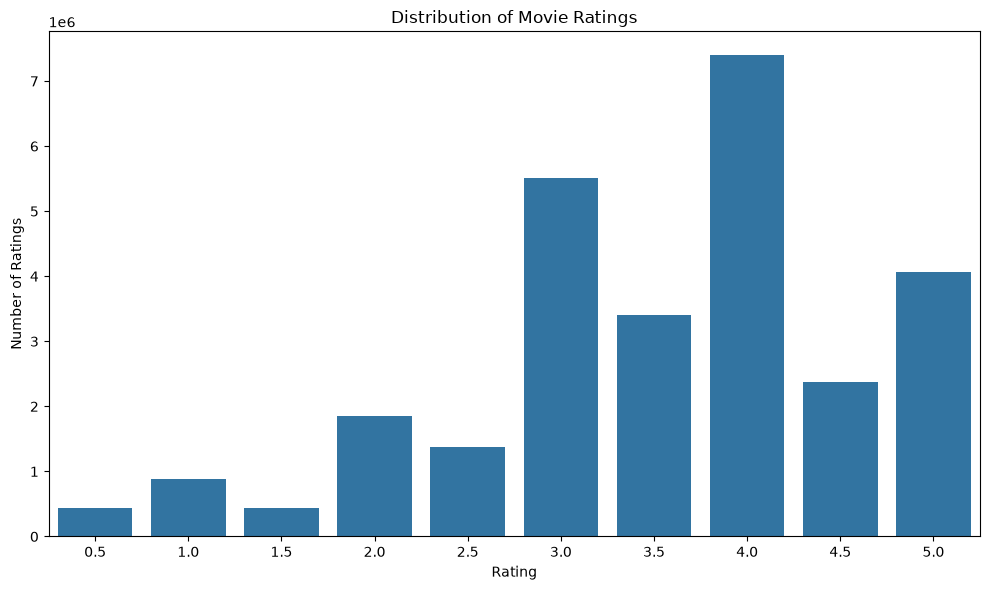

In [ ]:
plt.figure(figsize=(10, 6))

sns.countplot(
    x=ratings["rating"]
)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()